In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

In [3]:
raw = mne.io.read_raw_fif("/Users/patriciawatanabe/Desktop/Neurotech/Neurotech_UofT_2024/data/eeg_data/803_1_PD_REST-epo.fif", preload=True)

n_channels = len(raw.ch_names)
print(n_channels)

# raw.plot(scalings='auto', duration=10.0, n_channels=20)


Opening raw data file /Users/patriciawatanabe/Desktop/Neurotech/Neurotech_UofT_2024/data/eeg_data/803_1_PD_REST-epo.fif...
Isotrak not found
    Range : 0 ... 43224 =      0.000 ...    86.448 secs
Ready.
Reading 0 ... 43224  =      0.000 ...    86.448 secs...
63


/var/folders/lm/g0fsyqm52tjf6q4x94d9mdvw0000gn/T/ipykernel_12944/4275635645.py:1: RuntimeWarning: This filename (/Users/patriciawatanabe/Desktop/Neurotech/Neurotech_UofT_2024/data/eeg_data/803_1_PD_REST-epo.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif("/Users/patriciawatanabe/Desktop/Neurotech/Neurotech_UofT_2024/data/eeg_data/803_1_PD_REST-epo.fif", preload=True)


In [13]:
print(n_channels)

63


In [14]:
print(raw.times[-1])

86.448


In [ ]:
raw.plot(scalings='auto', duration=10.0, n_channels=20)

Using qt as 2D backend.
Using pyopengl with version 3.1.6


2025-05-06 11:32:22.694 python[12944:626200] +[IMKClient subclass]: chose IMKClient_Modern
2025-05-06 11:32:22.694 python[12944:626200] +[IMKInputSession subclass]: chose IMKInputSession_Modern


Channels marked as bad:
none
Attempting to create new mne-python configuration file:
/Users/patriciawatanabe/.mne/mne-python.json


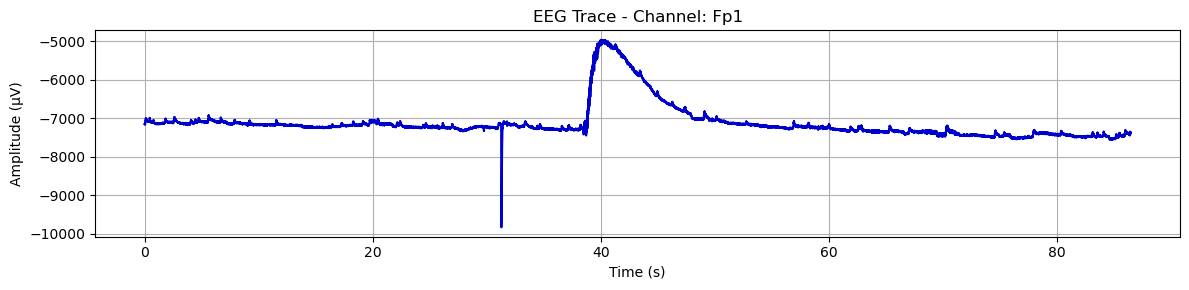

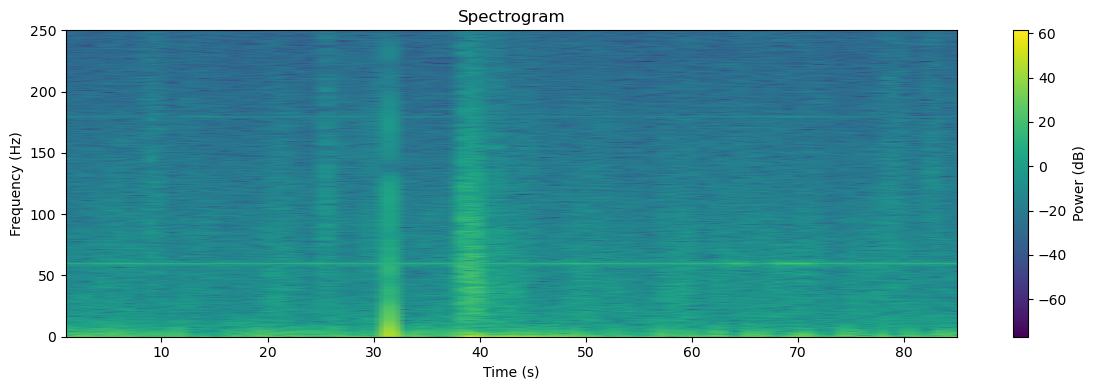

In [18]:
# Select one channel (e.g., Fp1)
channel = 'Fp1'
data, times = raw.get_data(picks=channel, return_times=True)
data = data[0]
fs = raw.info['sfreq']

# --- Plot 1: EEG trace (Time-Domain) ---
plt.figure(figsize=(12, 3))
plt.plot(times, data, color='mediumblue')
plt.title(f"EEG Trace - Channel: {channel}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Spectrogram (Time-Frequency Domain) ---
f, t_spec, Sxx = spectrogram(data, fs=fs, nperseg=int(fs*2), noverlap=int(fs))

plt.figure(figsize=(12, 4))
pcm = plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis')
plt.title("Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
cbar = plt.colorbar(pcm, label="Power (dB)")
plt.tight_layout()
plt.show()